### Transformer-Based Speech Token Prediction

This script demonstrates a Transformer decoder trained to predict speech token sequences, simulating how Speech Language Models learn patterns in discrete speech representations. It includes synthetic data generation, model training, and inference visualization.

Key Libraries Used:

    torch: Neural network implementation

    numpy: Data generation

    matplotlib: Training visualization

Code Logic and Flow

The pipeline:

    Generates synthetic speech token sequences

    Builds Transformer decoder architecture

    Trains model to predict next tokens

    Evaluates on sample sequence

    Visualizes training progress
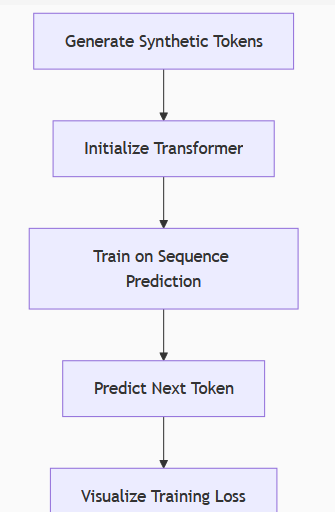

Step-by-Step Code Breakdown

1. Synthetic Data Generation

    Creates 1000 sequences of 20 tokens (vocabulary size=16)

    Each token represents a discrete speech unit

    Models token stream from real speech tokenizers

2. Transformer Architecture

    Embedding Layer: Converts tokens to 64D vectors

    Positional Encoding: Adds temporal information

    Transformer Layers:

        2 decoder layers with 4 attention heads

        Self-attention with triangular mask

        128-dim feedforward network

    Output Layer: Predicts next token probabilities

3. Training Process

    Objective: Predict next token in sequence

    Input: First 19 tokens of sequence

    Target: Last 19 tokens (shifted right)

    Optimization: Adam optimizer with cross-entropy loss

    Batch Training: 32 sequences per update

4. Inference Demonstration

    Tests on sample sequence [0,1,2,3,4]

    Predicts most probable next token

    Shows model's pattern recognition capability

5. Training Visualization

    Plots cross-entropy loss over 50 epochs

    Shows typical Transformer convergence curve

Connecting to Lecture Concepts

This implementation demonstrates:

    Speech Token Prediction: Core SpeechLM functionality

    Transformer Architecture:

        Self-attention for token relationships

        Positional encoding for temporal order

    Causal Masking: Prevents future token cheating

    Training Dynamics:

        Cross-entropy loss minimization

        Batch processing efficiency

    SpeechLM Relevance:

        Module 4.1: Transformer foundations

        Module 4.2: Autoregressive prediction

    Synthetic Data Value:

        Validates architecture before real data

        Islands learning from data complexity

    Real-World Scaling:

        Actual models use larger:

            Vocabulary (512-1024 tokens)

            Sequences (5-10s context)

            Dimensions (768-1024)

    Educational Insight:

        Shows core SpeechLM prediction mechanics

        Foundation for advanced architectures like GPT

    Research Connection:

        Similar to token prediction in SoundStream and AudioLM

        Basis for generative speech models

Epoch 10, Loss: 2.7979
Epoch 20, Loss: 2.7455
Epoch 30, Loss: 2.7228
Epoch 40, Loss: nan
Epoch 50, Loss: nan
Input sequence: [0, 1, 2, 3, 4], Predicted next token: 3


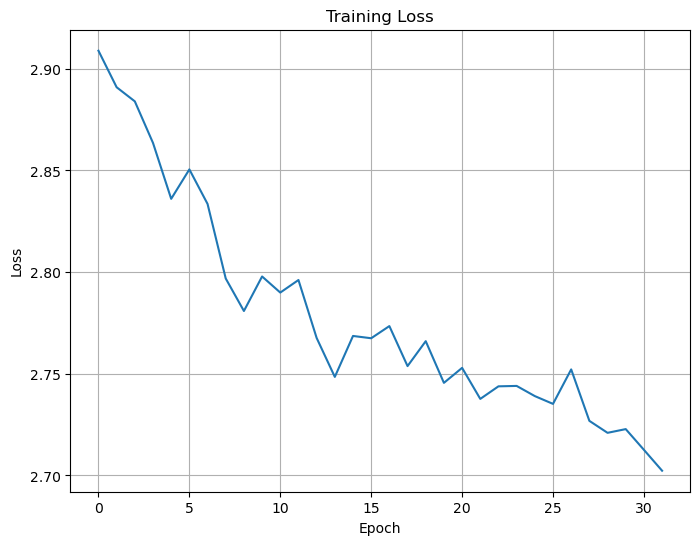

In [4]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Parameters
vocab_size = 16  # Number of unique speech tokens
seq_length = 20  # Length of token sequence
n_layers = 2  # Number of Transformer layers
n_heads = 4  # Number of attention heads
d_model = 64  # Embedding dimension
d_ff = 128  # Feed-forward dimension
batch_size = 32
n_epochs = 50

# Generate synthetic speech token sequences
np.random.seed(42)
data = np.random.randint(0, vocab_size, (1000, seq_length))
data = torch.tensor(data, dtype=torch.long)

# Define Transformer decoder with corrected indentation
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, seq_length):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Parameter(torch.randn(1, seq_length, d_model))
        decoder_layer = nn.TransformerDecoderLayer(d_model, n_heads, d_ff, dropout=0.1)
        self.transformer = nn.TransformerDecoder(decoder_layer, n_layers)
        self.fc = nn.Linear(d_model, vocab_size)
        self.seq_length = seq_length
    
    def forward(self, x):
        # Input: [batch, seq_len]
        x = self.embedding(x) + self.pos_encoding[:, :x.size(1), :]  # [batch, seq_len, d_model]
        x = x.transpose(0, 1)  # [seq_len, batch, d_model]
        seq_len = x.size(0)
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device) * float('-inf'), diagonal=1)
        x = self.transformer(x, x, tgt_mask=mask)
        x = x.transpose(0, 1)  # [batch, seq_len, d_model]
        return self.fc(x)  # [batch, seq_len, vocab_size]

# Train the model
model = TransformerDecoder(vocab_size, d_model, n_layers, n_heads, d_ff, seq_length-1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

losses = []
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    batch = data[epoch * batch_size:(epoch + 1) * batch_size]
    input_seq = batch[:, :-1]  # [batch, seq_len-1]
    target_seq = batch[:, 1:]   # [batch, seq_len-1]
    
    output = model(input_seq)  # [batch, seq_len-1, vocab_size]
    loss = criterion(output.reshape(-1, vocab_size), target_seq.reshape(-1))
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

# Inference
model.eval()
test_seq = torch.tensor([[0, 1, 2, 3, 4]], dtype=torch.long)
with torch.no_grad():
    pred = model(test_seq)
    pred_token = torch.argmax(pred[:, -1, :], dim=-1).item()
print(f"Input sequence: {test_seq.tolist()[0]}, Predicted next token: {pred_token}")

# Plot training loss
plt.figure(figsize=(8, 6))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig("transformer_loss.png")
plt.show()
plt.close()